In [832]:
# Cell: 01
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [833]:
# Cell: 02
pd.set_option('display.max_columns', None) #None tells pandas: “Do not limit the number of rows displayed.”
pd.set_option('display.max_rows', 10)

In [834]:
# Cell: 03
dataset = pd.read_csv('38_ev_range.csv')

In [835]:
# Cell: 04
dataset.head()

,manufacturer,vehicle_type,charging_type_last,drive_config,battery_chemistry,model_year,battery_capacity_kwh,battery_age_years,battery_health_pct,motor_power_kw,vehicle_weight_kg,drag_coefficient,tire_type,ambient_temp_c,hvac_usage,avg_speed_kmh,elevation_change_m,num_passengers,cargo_weight_kg,regenerative_braking,driving_mode,wind_speed_kmh,actual_range_km
0,Hyundai,NaN,Supercharger,FWD,LFP,2024.0,62.9,NaN,98.3,NaN,NaN,0.305,Low Rolling Resistance,38.1,Max Heat,NaN,349.9,NaN,270.0,Off,Chill,NaN,499.9
1,Tesla,Sports Car,Wireless,AWD,NCA,2024.0,49.9,2.0,79.0,679.0,1455.0,0.306,Low Rolling Resistance,-6.8,Max Heat,98.2,337.9,1.0,471.0,NaN,Chill,50.0,328.2
2,BMW,Truck,DC Fast Charge,FWD,Solid State,2015.0,29.6,6.0,73.0,455.0,NaN,0.329,Standard,13.7,Heating,123.1,65.7,2.0,NaN,High,Off-Road,60.5,421.7
3,NIO,Crossover,Wireless,AWD,NMC,2021.0,65.5,2.0,87.2,NaN,3812.0,0.433,All-Terrain,-1.6,Max Cool,NaN,NaN,5.0,45.0,Off,Sport,21.2,647.8
4,NIO,Crossover,NaN,FWD,NMC,2021.0,127.1,NaN,78.9,222.0,1842.0,0.434,Low Rolling Resistance,NaN,Heating,55.3,-248.0,3.0,169.0,Off,Off-Road,39.0,527.3


In [836]:
# Cell: 05
dataset.columns

Index(['manufacturer', 'vehicle_type', 'charging_type_last', 'drive_config',
       'battery_chemistry', 'model_year', 'battery_capacity_kwh',
       'battery_age_years', 'battery_health_pct', 'motor_power_kw',
       'vehicle_weight_kg', 'drag_coefficient', 'tire_type', 'ambient_temp_c',
       'hvac_usage', 'avg_speed_kmh', 'elevation_change_m', 'num_passengers',
       'cargo_weight_kg', 'regenerative_braking', 'driving_mode',
       'wind_speed_kmh', 'actual_range_km'],
      dtype='object')

In [837]:
# Cell: 06
dataset.describe()

,model_year,battery_capacity_kwh,battery_age_years,battery_health_pct,motor_power_kw,vehicle_weight_kg,drag_coefficient,ambient_temp_c,avg_speed_kmh,elevation_change_m,num_passengers,cargo_weight_kg,wind_speed_kmh,actual_range_km
count,828.000000,828.000000,846.000000,845.000000,846.000000,819.000000,832.000000,836.000000,823.000000,810.000000,832.000000,822.000000,836.000000,950.000000
mean,2019.508454,75.437319,4.477541,80.313609,386.212766,2555.907204,0.347552,12.734569,76.818104,4.523951,3.551683,246.574209,40.158254,481.627102
std,2.917848,31.727757,2.913562,11.687246,181.247452,774.757988,0.086873,18.657053,31.781272,287.708788,1.704308,140.318634,23.203074,656.342077
min,2015.000000,20.000000,0.000000,60.000000,50.000000,1204.000000,0.200000,-20.000000,20.200000,-499.700000,1.000000,0.000000,0.100000,80.100000
25%,2017.000000,48.175000,2.000000,70.700000,235.250000,1934.000000,0.275000,-2.825000,50.450000,-238.450000,2.000000,128.000000,20.475000,243.400000
50%,2020.000000,75.400000,5.000000,80.500000,393.000000,2552.000000,0.345000,12.500000,76.700000,16.050000,4.000000,241.000000,40.100000,389.550000
75%,2022.000000,102.625000,7.000000,90.500000,544.000000,3188.500000,0.420000,29.000000,103.950000,250.050000,5.000000,365.750000,60.575000,558.350000
max,2024.000000,130.000000,9.000000,100.000000,699.000000,3999.000000,0.500000,45.000000,130.000000,497.900000,6.000000,499.000000,79.700000,7158.274912


In [838]:
# dataset.info()
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   manufacturer          827 non-null    object 
 1   vehicle_type          830 non-null    object 
 2   charging_type_last    838 non-null    object 
 3   drive_config          836 non-null    object 
 4   battery_chemistry     822 non-null    object 
 5   model_year            828 non-null    float64
 6   battery_capacity_kwh  828 non-null    float64
 7   battery_age_years     846 non-null    float64
 8   battery_health_pct    845 non-null    float64
 9   motor_power_kw        846 non-null    float64
 10  vehicle_weight_kg     819 non-null    float64
 11  drag_coefficient      832 non-null    float64
 12  tire_type             834 non-null    object 
 13  ambient_temp_c        836 non-null    float64
 14  hvac_usage            705 non-null    object 
 15  avg_speed_kmh         8

In [839]:
# Cell: 07
#All numerical Columns
numerical_cols=dataset.select_dtypes(include=['int64','float64']).columns

In [840]:
# Cell: 08
dataset.shape

(950, 23)

In [841]:
# Cell: 09
numerical_cols

Index(['model_year', 'battery_capacity_kwh', 'battery_age_years',
       'battery_health_pct', 'motor_power_kw', 'vehicle_weight_kg',
       'drag_coefficient', 'ambient_temp_c', 'avg_speed_kmh',
       'elevation_change_m', 'num_passengers', 'cargo_weight_kg',
       'wind_speed_kmh', 'actual_range_km'],
      dtype='object')

In [842]:
# Cell: 10
len(numerical_cols)

14

In [843]:
# Cell: 11
#All categorical Columns
categorical_cols=dataset.select_dtypes(include='object').columns

In [844]:
# Cell: 12
categorical_cols

Index(['manufacturer', 'vehicle_type', 'charging_type_last', 'drive_config',
       'battery_chemistry', 'tire_type', 'hvac_usage', 'regenerative_braking',
       'driving_mode'],
      dtype='object')

In [845]:
# Cell: 13
len(categorical_cols)

9

In [846]:
# Cell: 14
dataset.dtypes

manufacturer             object
vehicle_type             object
charging_type_last       object
drive_config             object
battery_chemistry        object
                         ...   
cargo_weight_kg         float64
regenerative_braking     object
driving_mode             object
wind_speed_kmh          float64
actual_range_km         float64
Length: 23, dtype: object

In [847]:
# Cell: 15
dataset.isnull() #list All nulls

,manufacturer,vehicle_type,charging_type_last,drive_config,battery_chemistry,model_year,battery_capacity_kwh,battery_age_years,battery_health_pct,motor_power_kw,vehicle_weight_kg,drag_coefficient,tire_type,ambient_temp_c,hvac_usage,avg_speed_kmh,elevation_change_m,num_passengers,cargo_weight_kg,regenerative_braking,driving_mode,wind_speed_kmh,actual_range_km
0,False,True,False,False,False,False,False,True,False,True,True,False,False,False,False,True,False,True,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,True,False,False,False,False,False,False
4,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
946,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
947,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False
948,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False


In [848]:
# Cell: 16
dataset.isnull().values.any()   #any nulls available?

np.True_

In [849]:
# Cell: 17
dataset.isnull().values.sum()   #count all columns nulls

np.int64(2735)

In [850]:
# Cell: 18
dataset.isnull().sum()   #counts null in each columns

manufacturer            123
vehicle_type            120
charging_type_last      112
drive_config            114
battery_chemistry       128
                       ... 
cargo_weight_kg         128
regenerative_braking    109
driving_mode            121
wind_speed_kmh          114
actual_range_km           0
Length: 23, dtype: int64

In [851]:
# Cell: 19
dataset.shape

(950, 23)

In [852]:
# Cell: 20
# columns with null values
dataset.columns[dataset.isnull().any()]

Index(['manufacturer', 'vehicle_type', 'charging_type_last', 'drive_config',
       'battery_chemistry', 'model_year', 'battery_capacity_kwh',
       'battery_age_years', 'battery_health_pct', 'motor_power_kw',
       'vehicle_weight_kg', 'drag_coefficient', 'tire_type', 'ambient_temp_c',
       'hvac_usage', 'avg_speed_kmh', 'elevation_change_m', 'num_passengers',
       'cargo_weight_kg', 'regenerative_braking', 'driving_mode',
       'wind_speed_kmh'],
      dtype='object')

In [853]:
# Cell: 21
len(dataset.columns[dataset.isnull().any()])

22

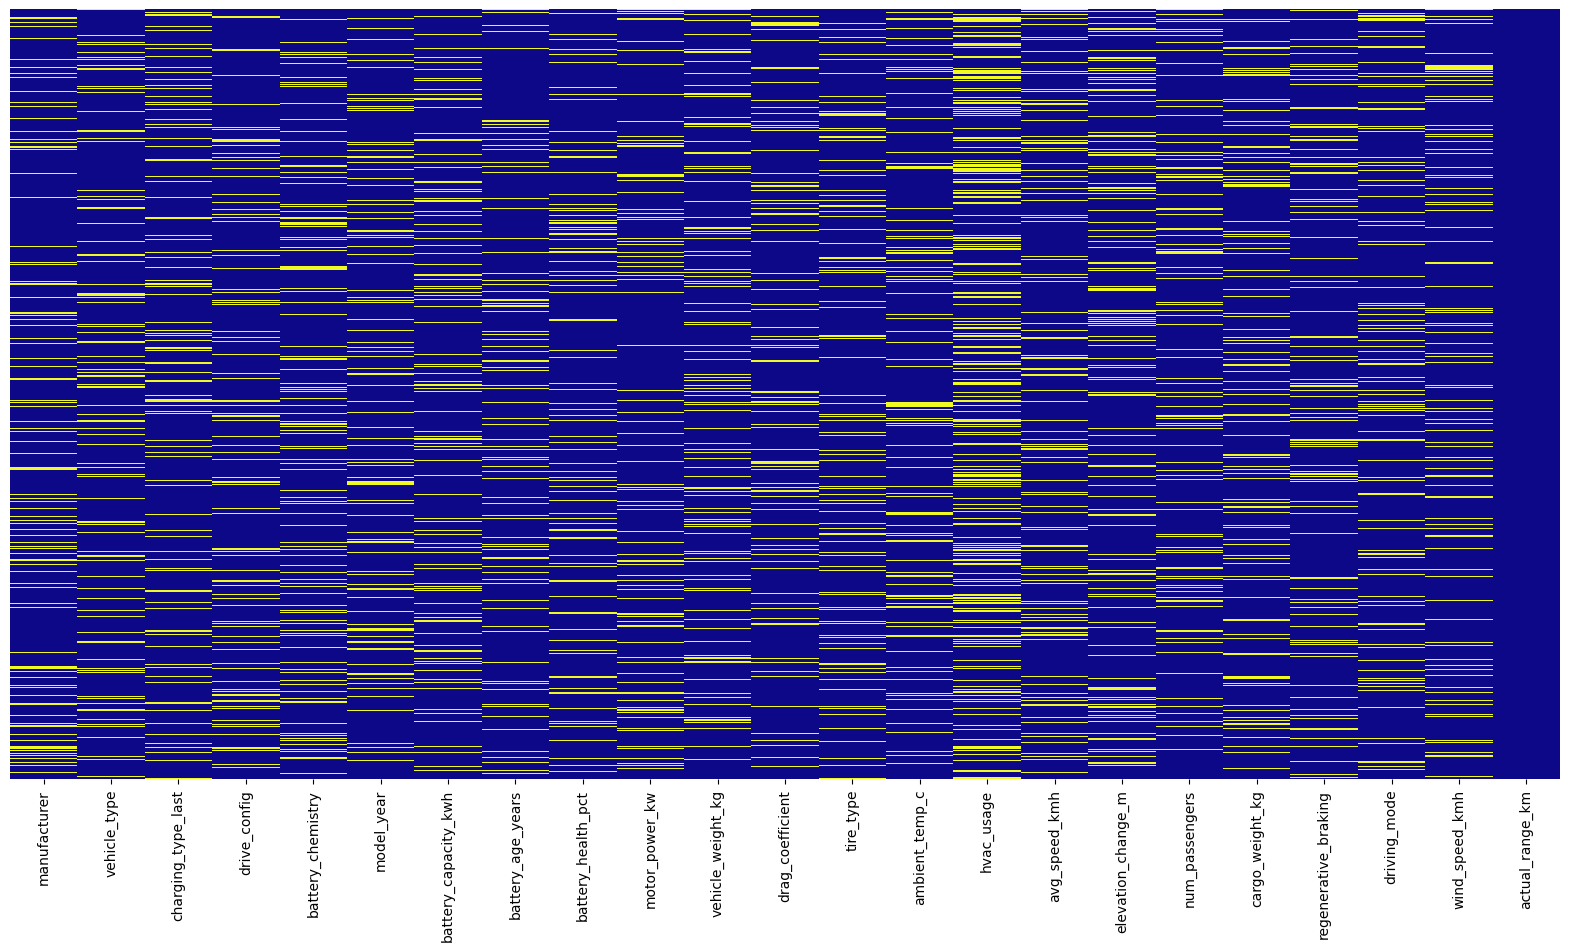

In [854]:
# Cell: 22
plt.figure(figsize=(20,10))
sns.heatmap(dataset.isnull(),yticklabels=False,cbar=False,cmap='plasma')  #Set2, plasma, inferno, magma, cividis, Blues, Greens, Oranges, Reds
plt.show()

In [855]:
# Cell: 23
null_percentage=dataset.isnull().sum()/dataset.shape[0]*100

In [856]:
# Cell: 24
print(null_percentage)

manufacturer            12.947368
vehicle_type            12.631579
charging_type_last      11.789474
drive_config            12.000000
battery_chemistry       13.473684
                          ...    
cargo_weight_kg         13.473684
regenerative_braking    11.473684
driving_mode            12.736842
wind_speed_kmh          12.000000
actual_range_km          0.000000
Length: 23, dtype: float64


In [857]:
# Cell: 25
# columns to drop (more than 50% null values)
cols_to_drop = null_percentage[null_percentage > 50].keys()
cols_to_drop = null_percentage[null_percentage > 50]

In [858]:
# Cell: 26
cols_to_drop

Series([], dtype: float64)

In [859]:
# Cell: 27
cols_to_drop.keys() # no column to drop

Index([], dtype='object')

In [860]:
# Cell: 28
# check catagorical columns
dataset.select_dtypes(include='object').columns

Index(['manufacturer', 'vehicle_type', 'charging_type_last', 'drive_config',
       'battery_chemistry', 'tire_type', 'hvac_usage', 'regenerative_braking',
       'driving_mode'],
      dtype='object')

In [861]:
# Cell: 29
# lenght of cat cols
len(dataset.select_dtypes(include = 'object').columns)


9

In [862]:
# Cell: 30
dataset.select_dtypes(include=['int64','float64']).columns

Index(['model_year', 'battery_capacity_kwh', 'battery_age_years',
       'battery_health_pct', 'motor_power_kw', 'vehicle_weight_kg',
       'drag_coefficient', 'ambient_temp_c', 'avg_speed_kmh',
       'elevation_change_m', 'num_passengers', 'cargo_weight_kg',
       'wind_speed_kmh', 'actual_range_km'],
      dtype='object')

In [863]:
# Cell: 31
numerical_cols[dataset.select_dtypes(include=['int64','float64']).isnull().any()]

Index(['model_year', 'battery_capacity_kwh', 'battery_age_years',
       'battery_health_pct', 'motor_power_kw', 'vehicle_weight_kg',
       'drag_coefficient', 'ambient_temp_c', 'avg_speed_kmh',
       'elevation_change_m', 'num_passengers', 'cargo_weight_kg',
       'wind_speed_kmh'],
      dtype='object')

In [864]:
# Cell: 32
len(numerical_cols[dataset.select_dtypes(include=['int64','float64']).isnull().any()])

13

In [865]:
# Cell: 33
#Place mean in the null places
dataset['model_year']=dataset['model_year'].fillna(dataset['model_year'].mean())

In [866]:
# Cell: 34
# fill while using a for loop--- convenient
null_num_cols=numerical_cols[dataset.select_dtypes(include=['int64','float64']).isnull().any()]

for col in null_num_cols:
    dataset[col]=dataset[col].fillna(dataset[col].mean())


In [867]:
# Cell: 35
# check num cols as null if 
numerical_cols[dataset.select_dtypes(include=['int64','float64']).isnull().any()]

Index([], dtype='object')

In [868]:
# Cell: 36
len(dataset.columns[dataset.isnull().any()]) # these are categorical columns 

9

# Add columns mode to categorical columns

In [869]:
# Cell: 37
dataset.select_dtypes(include='object').columns

Index(['manufacturer', 'vehicle_type', 'charging_type_last', 'drive_config',
       'battery_chemistry', 'tire_type', 'hvac_usage', 'regenerative_braking',
       'driving_mode'],
      dtype='object')

In [870]:
len(dataset.select_dtypes(include='object').columns)

9

In [871]:
# Cell: 38
dataset.columns[dataset.isnull().any()]  #categorical columns with nulls

Index(['manufacturer', 'vehicle_type', 'charging_type_last', 'drive_config',
       'battery_chemistry', 'tire_type', 'hvac_usage', 'regenerative_braking',
       'driving_mode'],
      dtype='object')

In [872]:
# Cell: 39
len(dataset.columns[dataset.isnull().any()] )

9

In [873]:
# Cell: 40
# fill while using mode 
dataset['manufacturer']=dataset['manufacturer'].fillna(dataset['manufacturer'].mode()[0])

In [874]:
#Cell: 41
# using for loop 
null_cat_cols=dataset.columns[dataset.isnull().any()]

for col in null_cat_cols:
    dataset[col]=dataset[col].fillna(dataset[col].mode()[0])

In [875]:
# Cell: 42
dataset['manufacturer'].mode()

0    BYD
Name: manufacturer, dtype: object

In [876]:
# Cell: 43
len(dataset.columns[dataset.isnull().any()]) #check nulls

0

In [877]:
# Cell: 44
dataset.isnull().values.any()

np.False_

In [878]:
dataset.columns

Index(['manufacturer', 'vehicle_type', 'charging_type_last', 'drive_config',
       'battery_chemistry', 'model_year', 'battery_capacity_kwh',
       'battery_age_years', 'battery_health_pct', 'motor_power_kw',
       'vehicle_weight_kg', 'drag_coefficient', 'tire_type', 'ambient_temp_c',
       'hvac_usage', 'avg_speed_kmh', 'elevation_change_m', 'num_passengers',
       'cargo_weight_kg', 'regenerative_braking', 'driving_mode',
       'wind_speed_kmh', 'actual_range_km'],
      dtype='object')

In [879]:
dataset.head()

,manufacturer,vehicle_type,charging_type_last,drive_config,battery_chemistry,model_year,battery_capacity_kwh,battery_age_years,battery_health_pct,motor_power_kw,vehicle_weight_kg,drag_coefficient,tire_type,ambient_temp_c,hvac_usage,avg_speed_kmh,elevation_change_m,num_passengers,cargo_weight_kg,regenerative_braking,driving_mode,wind_speed_kmh,actual_range_km
0,Hyundai,Hatchback,Supercharger,FWD,LFP,2024.0,62.9,4.477541,98.3,386.212766,2555.907204,0.305,Low Rolling Resistance,38.100000,Max Heat,76.818104,349.900000,3.551683,270.000000,Off,Chill,40.158254,499.9
1,Tesla,Sports Car,Wireless,AWD,NCA,2024.0,49.9,2.000000,79.0,679.000000,1455.000000,0.306,Low Rolling Resistance,-6.800000,Max Heat,98.200000,337.900000,1.000000,471.000000,Off,Chill,50.000000,328.2
2,BMW,Truck,DC Fast Charge,FWD,Solid State,2015.0,29.6,6.000000,73.0,455.000000,2555.907204,0.329,Standard,13.700000,Heating,123.100000,65.700000,2.000000,246.574209,High,Off-Road,60.500000,421.7
3,NIO,Crossover,Wireless,AWD,NMC,2021.0,65.5,2.000000,87.2,386.212766,3812.000000,0.433,All-Terrain,-1.600000,Max Cool,76.818104,4.523951,5.000000,45.000000,Off,Sport,21.200000,647.8
4,NIO,Crossover,Supercharger,FWD,NMC,2021.0,127.1,4.477541,78.9,222.000000,1842.000000,0.434,Low Rolling Resistance,12.734569,Heating,55.300000,-248.000000,3.000000,169.000000,Off,Off-Road,39.000000,527.3


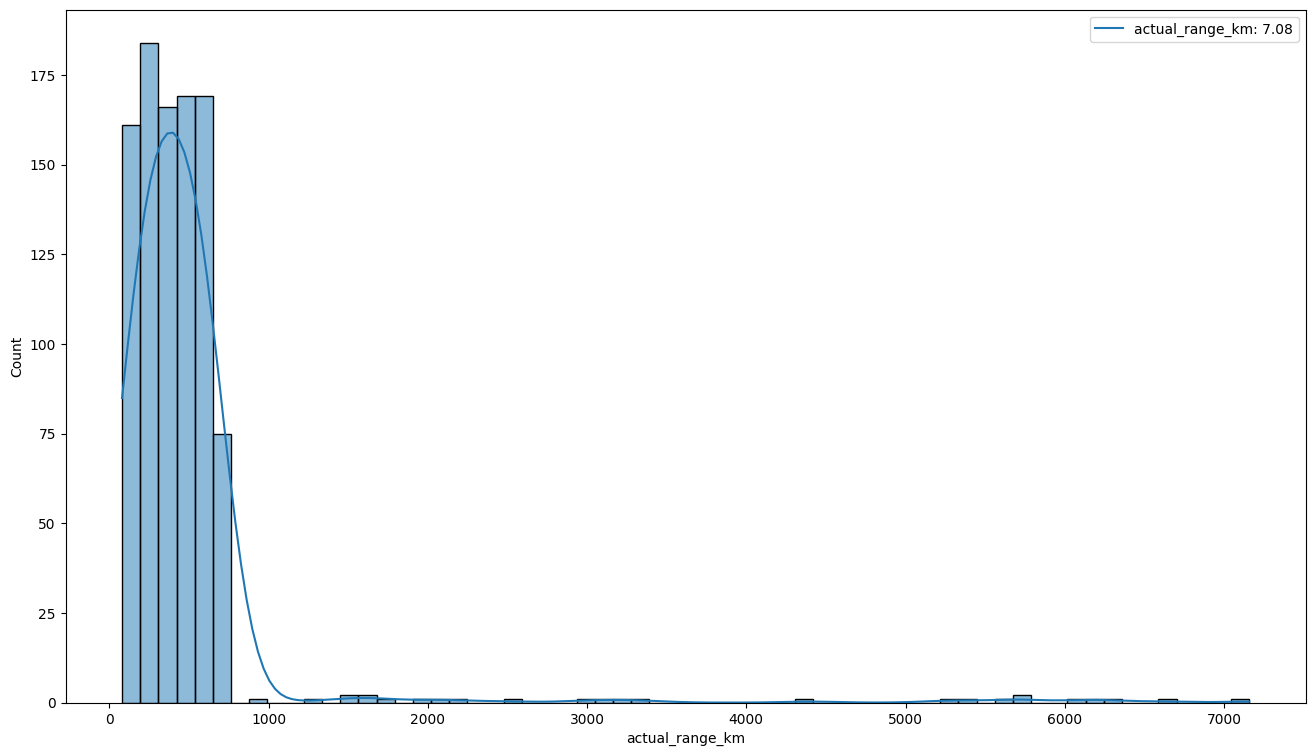

In [880]:
# Cell: 45
plt.figure(figsize = (16,9))
bar = sns.histplot(dataset['actual_range_km'], kde = True)
bar.legend(['actual_range_km: {:.2f}'.format(dataset['actual_range_km'].skew())])
plt.show()

In [881]:
# Cell: 46
dataset_2 = dataset.drop(columns = 'actual_range_km')

In [882]:
# Cell: 47
dataset_2.shape

(950, 22)

<Axes: title={'center': 'Correlated with actual_range_km'}>

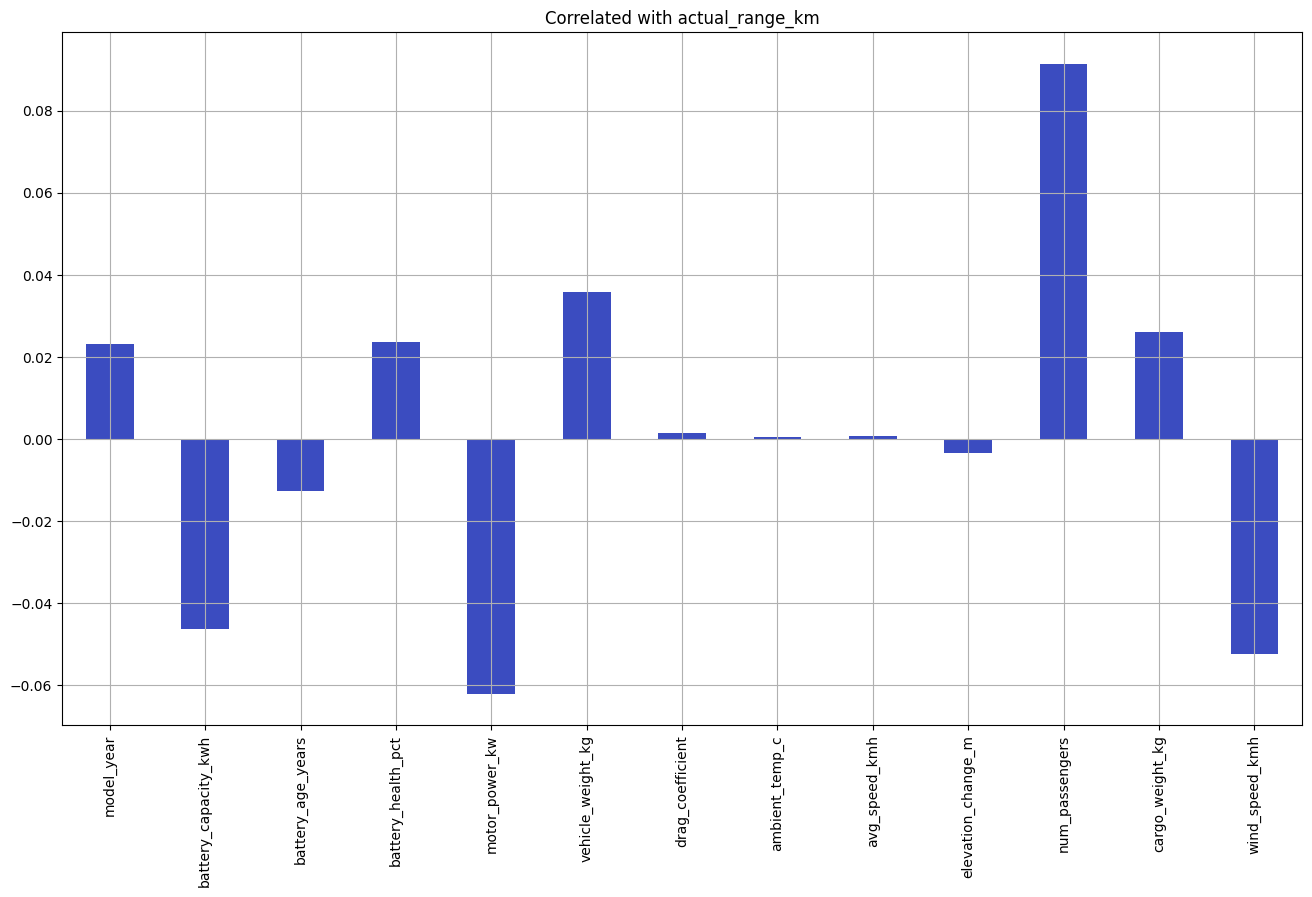

In [883]:
# Cell: 48
dataset_2.select_dtypes(include ='number').corrwith(dataset['actual_range_km']).plot.bar(
    figsize=(16,9), title = 'Correlated with actual_range_km', grid = True, colormap='coolwarm'
)

<Axes: title={'center': 'Correlated with actual_range_km'}>

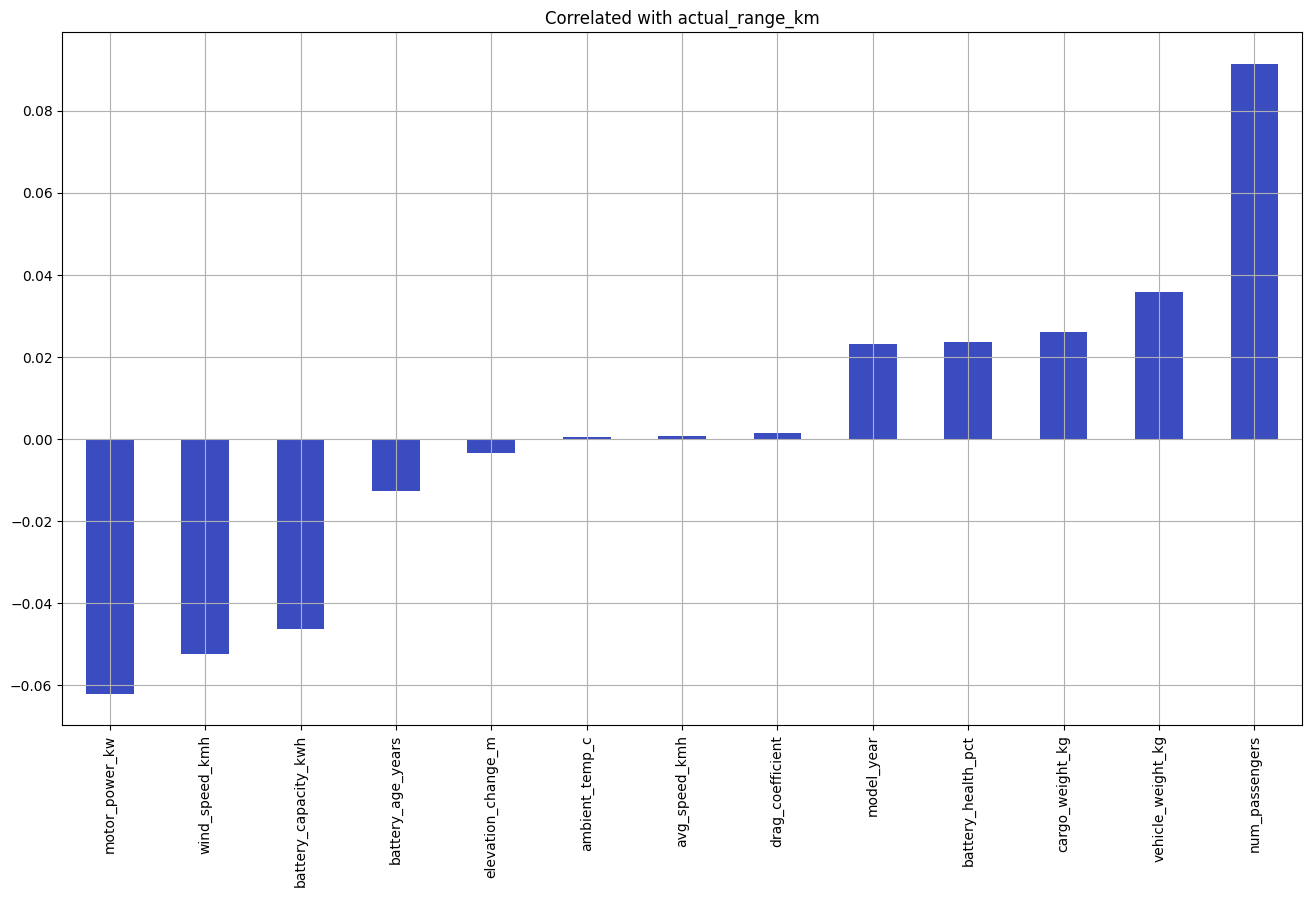

In [884]:
# Cell: 49
dataset_2.select_dtypes(include ='number').corrwith(dataset['actual_range_km']).sort_values().plot.bar(
    figsize=(16,9), title = 'Correlated with actual_range_km', grid = True, colormap='coolwarm'
)

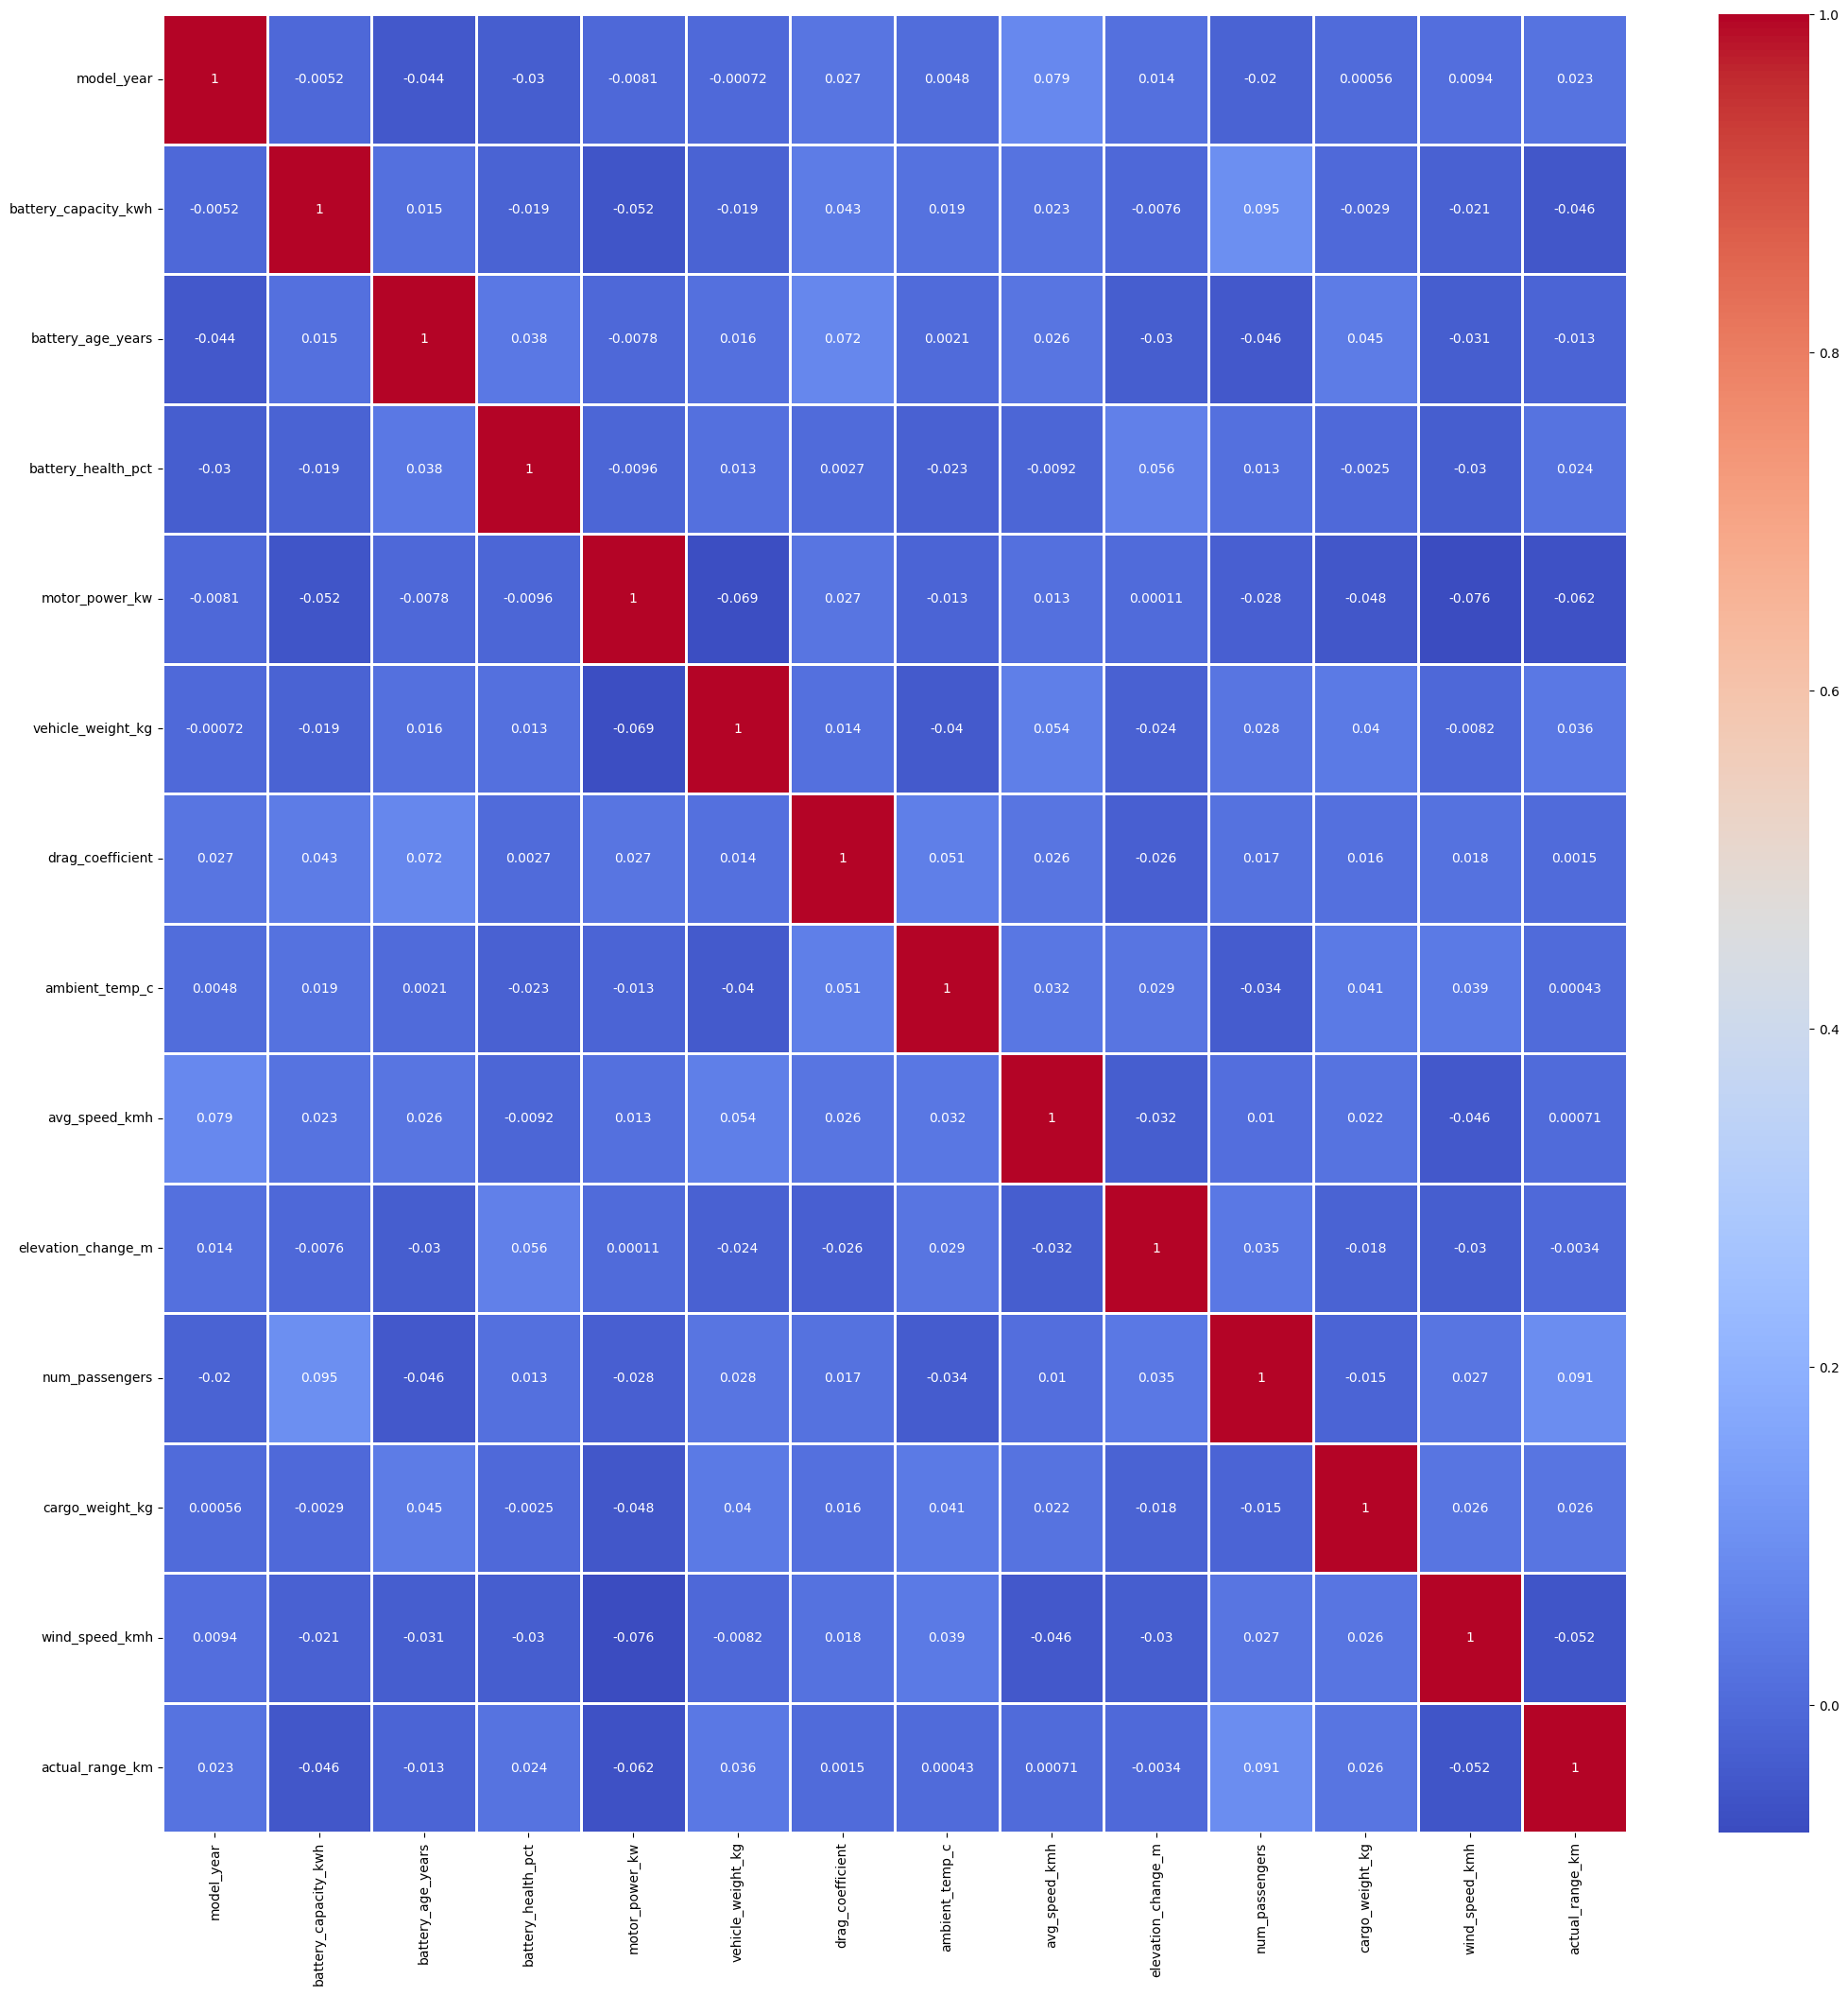

In [885]:
# Cell: 50
#heatmap

plt.figure(figsize =(25, 25))
ax = sns.heatmap(data = dataset.select_dtypes(include ='number').corr(), cmap = 'coolwarm', annot= True, linewidth=2)

In [886]:
    # Cell: 51
high_corr = dataset.select_dtypes(include = 'number').corr()

In [887]:
# Cell: 52
high_corr_feetures = high_corr.index[abs(high_corr['actual_range_km']>0.5)]

In [888]:
# Cell: 53
high_corr_feetures

Index(['actual_range_km'], dtype='object')

In [889]:
# Cell: 54
len(high_corr_feetures)

1

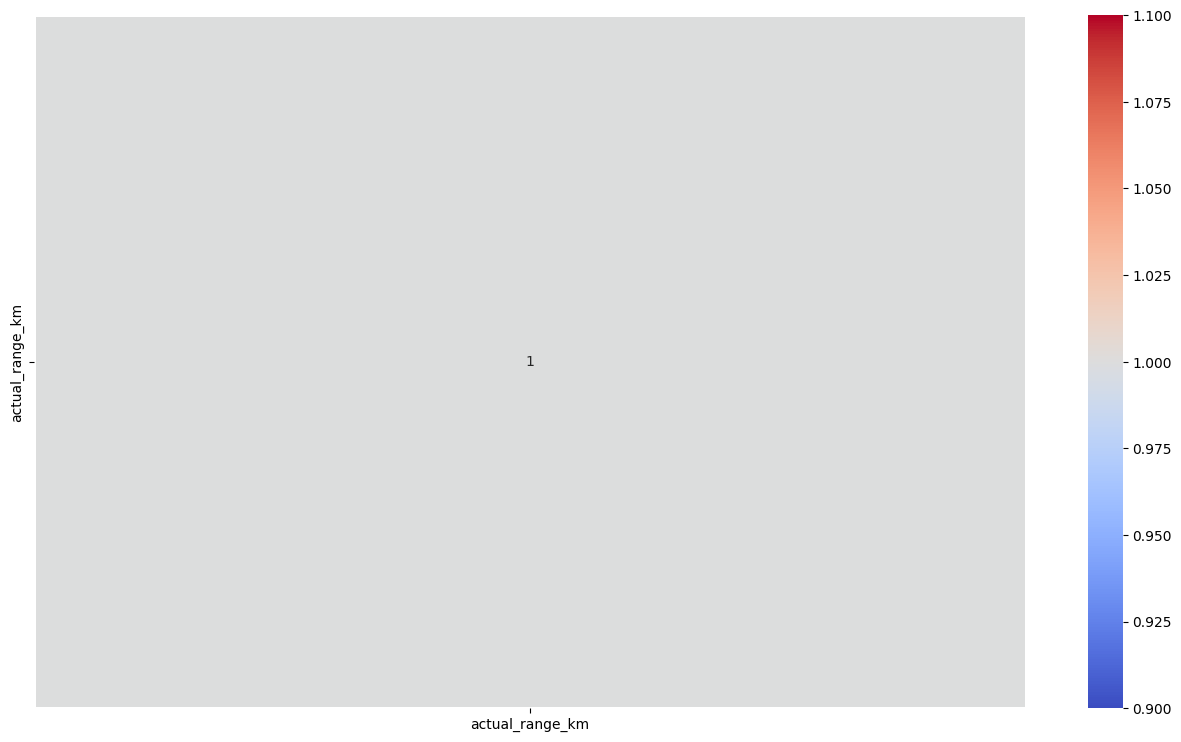

In [890]:
# Cell: 55
#heatmap
plt.figure(figsize =(16, 9))
ax = sns.heatmap(data = dataset[high_corr_feetures].select_dtypes(include ='number').corr(), cmap = 'coolwarm', annot= True, linewidth=2)

In [891]:
# Cell: 56
dataset.shape

(950, 23)

In [892]:
# Cell: 57
# list categorical columns
dataset.select_dtypes(include = 'object').columns

Index(['manufacturer', 'vehicle_type', 'charging_type_last', 'drive_config',
       'battery_chemistry', 'tire_type', 'hvac_usage', 'regenerative_braking',
       'driving_mode'],
      dtype='object')

In [893]:
# Cell: 58
dataset.head()

,manufacturer,vehicle_type,charging_type_last,drive_config,battery_chemistry,model_year,battery_capacity_kwh,battery_age_years,battery_health_pct,motor_power_kw,vehicle_weight_kg,drag_coefficient,tire_type,ambient_temp_c,hvac_usage,avg_speed_kmh,elevation_change_m,num_passengers,cargo_weight_kg,regenerative_braking,driving_mode,wind_speed_kmh,actual_range_km
0,Hyundai,Hatchback,Supercharger,FWD,LFP,2024.0,62.9,4.477541,98.3,386.212766,2555.907204,0.305,Low Rolling Resistance,38.100000,Max Heat,76.818104,349.900000,3.551683,270.000000,Off,Chill,40.158254,499.9
1,Tesla,Sports Car,Wireless,AWD,NCA,2024.0,49.9,2.000000,79.0,679.000000,1455.000000,0.306,Low Rolling Resistance,-6.800000,Max Heat,98.200000,337.900000,1.000000,471.000000,Off,Chill,50.000000,328.2
2,BMW,Truck,DC Fast Charge,FWD,Solid State,2015.0,29.6,6.000000,73.0,455.000000,2555.907204,0.329,Standard,13.700000,Heating,123.100000,65.700000,2.000000,246.574209,High,Off-Road,60.500000,421.7
3,NIO,Crossover,Wireless,AWD,NMC,2021.0,65.5,2.000000,87.2,386.212766,3812.000000,0.433,All-Terrain,-1.600000,Max Cool,76.818104,4.523951,5.000000,45.000000,Off,Sport,21.200000,647.8
4,NIO,Crossover,Supercharger,FWD,NMC,2021.0,127.1,4.477541,78.9,222.000000,1842.000000,0.434,Low Rolling Resistance,12.734569,Heating,55.300000,-248.000000,3.000000,169.000000,Off,Off-Road,39.000000,527.3


In [894]:
num_cols=dataset.select_dtypes(include=['float64','int64']).columns

In [895]:
len(num_cols)

14

In [896]:
cat_cols=dataset.select_dtypes(include='object').columns

In [897]:
len(cat_cols)

9

In [898]:
print(dataset['manufacturer'].nunique())
# using for loop
for col in cat_cols:
    print(col,':',dataset[col].nunique())


30
manufacturer : 30
vehicle_type : 7
charging_type_last : 5
drive_config : 4
battery_chemistry : 5
tire_type : 4
hvac_usage : 4
regenerative_braking : 5
driving_mode : 5


In [899]:
total_dummies=sum(dataset[col].nunique()-1 for col in cat_cols)
print(total_dummies)

60


In [900]:
len(num_cols) # so total columns will be 74

14

In [901]:
# Cell: 59
#is used to convert categorical/text columns into numerical columns because 
# Machine Learning models like Linear Regression cannot work with text data directly.
dataset = pd.get_dummies(data = dataset, drop_first = True)

In [902]:
# Cell: 60
dataset.shape

(950, 74)

In [903]:
# Cell: 61
dataset.head()

,model_year,battery_capacity_kwh,battery_age_years,battery_health_pct,motor_power_kw,vehicle_weight_kg,drag_coefficient,ambient_temp_c,avg_speed_kmh,elevation_change_m,num_passengers,cargo_weight_kg,wind_speed_kmh,actual_range_km,manufacturer_Audi,manufacturer_BMW,manufacturer_BYD,manufacturer_BYD,manufacturer_HYUNDAI,manufacturer_Hyundai,manufacturer_LUCID,manufacturer_Lucid,manufacturer_NIO,manufacturer_NIO,manufacturer_POLESTAR,manufacturer_Polestar,manufacturer_RIVIAN,manufacturer_Rivian,manufacturer_TESLA,manufacturer_Tesla,manufacturer_VW,manufacturer_audi,manufacturer_bmw,manufacturer_byd,manufacturer_hyundai,manufacturer_lucid,manufacturer_nio,manufacturer_polestar,manufacturer_rivian,manufacturer_rivin,manufacturer_tesla,manufacturer_tesla,manufacturer_vw,vehicle_type_Hatchback,vehicle_type_SUV,vehicle_type_Sedan,vehicle_type_Sports Car,vehicle_type_Truck,vehicle_type_Van,charging_type_last_Level 1,charging_type_last_Level 2,charging_type_last_Supercharger,charging_type_last_Wireless,drive_config_AWD,drive_config_FWD,drive_config_RWD,battery_chemistry_NCA,battery_chemistry_NMC,battery_chemistry_NMCA,battery_chemistry_Solid State,tire_type_Low Rolling Resistance,tire_type_Performance,tire_type_Standard,hvac_usage_Heating,hvac_usage_Max Cool,hvac_usage_Max Heat,regenerative_braking_Low,regenerative_braking_Max,regenerative_braking_Medium,regenerative_braking_Off,driving_mode_Eco,driving_mode_Normal,driving_mode_Off-Road,driving_mode_Sport
0,2024.0,62.9,4.477541,98.3,386.212766,2555.907204,0.305,38.100000,76.818104,349.900000,3.551683,270.000000,40.158254,499.9,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False
1,2024.0,49.9,2.000000,79.0,679.000000,1455.000000,0.306,-6.800000,98.200000,337.900000,1.000000,471.000000,50.000000,328.2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,True,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False
2,2015.0,29.6,6.000000,73.0,455.000000,2555.907204,0.329,13.700000,123.100000,65.700000,2.000000,246.574209,60.500000,421.7,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,True,False,False,False,False,False,False,False,False,True,False
3,2021.0,65.5,2.000000,87.2,386.212766,3812.000000,0.433,-1.600000,76.818104,4.523951,5.000000,45.000000,21.200000,647.8,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True
4,2021.0,127.1,4.477541,78.9,222.000000,1842.000000,0.434,12.734569,55.300000,-248.000000,3.000000,169.000000,39.000000,527.3,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True,False,False,True,False


In [904]:
# Cell: 58
# list categorical columns
dataset.select_dtypes(include = 'object').columns

Index([], dtype='object')

In [905]:
# Cell: 59
len(dataset.select_dtypes(include = 'object').columns)

0

In [906]:
# Cell: 60
dataset.head()

,model_year,battery_capacity_kwh,battery_age_years,battery_health_pct,motor_power_kw,vehicle_weight_kg,drag_coefficient,ambient_temp_c,avg_speed_kmh,elevation_change_m,num_passengers,cargo_weight_kg,wind_speed_kmh,actual_range_km,manufacturer_Audi,manufacturer_BMW,manufacturer_BYD,manufacturer_BYD,manufacturer_HYUNDAI,manufacturer_Hyundai,manufacturer_LUCID,manufacturer_Lucid,manufacturer_NIO,manufacturer_NIO,manufacturer_POLESTAR,manufacturer_Polestar,manufacturer_RIVIAN,manufacturer_Rivian,manufacturer_TESLA,manufacturer_Tesla,manufacturer_VW,manufacturer_audi,manufacturer_bmw,manufacturer_byd,manufacturer_hyundai,manufacturer_lucid,manufacturer_nio,manufacturer_polestar,manufacturer_rivian,manufacturer_rivin,manufacturer_tesla,manufacturer_tesla,manufacturer_vw,vehicle_type_Hatchback,vehicle_type_SUV,vehicle_type_Sedan,vehicle_type_Sports Car,vehicle_type_Truck,vehicle_type_Van,charging_type_last_Level 1,charging_type_last_Level 2,charging_type_last_Supercharger,charging_type_last_Wireless,drive_config_AWD,drive_config_FWD,drive_config_RWD,battery_chemistry_NCA,battery_chemistry_NMC,battery_chemistry_NMCA,battery_chemistry_Solid State,tire_type_Low Rolling Resistance,tire_type_Performance,tire_type_Standard,hvac_usage_Heating,hvac_usage_Max Cool,hvac_usage_Max Heat,regenerative_braking_Low,regenerative_braking_Max,regenerative_braking_Medium,regenerative_braking_Off,driving_mode_Eco,driving_mode_Normal,driving_mode_Off-Road,driving_mode_Sport
0,2024.0,62.9,4.477541,98.3,386.212766,2555.907204,0.305,38.100000,76.818104,349.900000,3.551683,270.000000,40.158254,499.9,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False
1,2024.0,49.9,2.000000,79.0,679.000000,1455.000000,0.306,-6.800000,98.200000,337.900000,1.000000,471.000000,50.000000,328.2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,True,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False
2,2015.0,29.6,6.000000,73.0,455.000000,2555.907204,0.329,13.700000,123.100000,65.700000,2.000000,246.574209,60.500000,421.7,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,True,False,False,False,False,False,False,False,False,True,False
3,2021.0,65.5,2.000000,87.2,386.212766,3812.000000,0.433,-1.600000,76.818104,4.523951,5.000000,45.000000,21.200000,647.8,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True
4,2021.0,127.1,4.477541,78.9,222.000000,1842.000000,0.434,12.734569,55.300000,-248.000000,3.000000,169.000000,39.000000,527.3,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True,False,False,True,False


In [924]:
corr = dataset.corr(numeric_only=True)['actual_range_km'].abs()

strong_features = corr[corr > 0.2].index
strong_features

Index(['actual_range_km'], dtype='object')

# Splitting the dataset

In [907]:
# Cell: 61
# independ variables / matrix of features
x = dataset.drop(columns = 'actual_range_km')

In [908]:
# Cell: 62
# target variables / dependent variable
y = dataset['actual_range_km']

In [909]:
#pip install scikit-learn

In [910]:
# Cell: 63
from sklearn.model_selection import train_test_split

In [925]:
# Cell: 64
x_train ,x_test, y_train, y_test  = train_test_split(x, y, test_size=0.2 , random_state=0)

In [926]:
# Cell: 65
x_train.shape

(760, 73)

In [927]:
# Cell: 66
y_train.shape

(760,)

In [928]:
# Cell: 67
x_test.shape

(190, 73)

In [929]:
# Cell: 68
y_test.shape

(190,)

In [930]:
# Cell: 69
# feature scaling - 
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [931]:
# Cell: 70
x_train

array([[-0.54981849, -1.29366726, -0.53932676, ..., -0.46056619,
        -0.44367825, -0.67523233],
       [ 0.92883192,  0.38673849, -0.90124433, ..., -0.46056619,
        -0.44367825,  1.48097175],
       [ 0.55916932,  0.3296047 , -0.53932676, ..., -0.46056619,
         2.25388553, -0.67523233],
       ...,
       [ 1.29849453, -1.12898749,  1.27026111, ..., -0.46056619,
         2.25388553, -0.67523233],
       [ 0.00780058,  0.54133582,  0.18450839, ..., -0.46056619,
        -0.44367825,  1.48097175],
       [-1.6588063 , -1.49195513, -1.2631619 , ..., -0.46056619,
        -0.44367825, -0.67523233]], shape=(760, 73))

In [918]:
# Cell: 71
from sklearn.linear_model import LinearRegression

In [932]:
# Cell: 72
regressor_mlr = LinearRegression()
regressor_mlr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [920]:
# Cell: 73
y_pred = regressor_mlr.predict(x_test)

In [921]:
# Cell: 74
from sklearn.metrics import r2_score

In [933]:
# Cell: 75
r2_score(y_test, y_pred)

-0.4039498892373836

In [ ]:
# Note:
# No strong linear relationship was found between independent variables 
# and target variable using correlation analysis. Therefore, Linear Regression 
# shows limited performance because the dataset contains non-linear relationships.